In [56]:
import sqlite3
import pandas as pd
import numpy as np


DB_PATH = "dm_project_2y.db"
conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

In [57]:
#creo la tabella
cur.executescript("""
DROP TABLE IF EXISTS enriched_hourly_2y;
CREATE TABLE enriched_hourly_2y (
  asset TEXT NOT NULL,
  ts_hour_utc TEXT NOT NULL,
  open REAL, high REAL, low REAL, close REAL, volume REAL,
  n_trades INTEGER,
  news_count_hour INTEGER,
  avg_tone_hour REAL,
  news_share_hour REAL,
  gdelt_missing INTEGER,
  ret_1h REAL,
  log_close REAL,
  hl_range_pct REAL,
  news_spike INTEGER,
  news_p95 REAL,
  PRIMARY KEY (asset, ts_hour_utc)
);
""")
conn.commit()


In [30]:
df = pd.read_csv("enriched_hourly_2y.csv")
df["ts_hour_utc"] = pd.to_datetime(df["ts_hour_utc"], utc=True, errors="coerce")\
                      .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
if "gdelt_missing" in df.columns:
    df["gdelt_missing"] = df["gdelt_missing"].fillna(0).astype(int)
df.to_sql("enriched_hourly_2y", conn, if_exists="append", index=False)

87600

In [4]:
pd.read_sql_query("SELECT COUNT(*) AS n FROM enriched_hourly_2y;", conn)

,n
0,87600


In [31]:
%%sql
--query per movimento futuro
WITH x AS (
  SELECT
    asset,
    ts_hour_utc,
    news_spike,

    SUM(ABS(ret_1h)) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 1 FOLLOWING
    ) AS fwd_move_1h,

    SUM(ABS(ret_1h)) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 6 FOLLOWING
    ) AS fwd_move_6h,

    SUM(ABS(ret_1h)) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING
    ) AS fwd_move_24h,

    COUNT(ret_1h) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING
    ) AS n24
  FROM enriched_hourly_2y
  WHERE gdelt_missing = 0
)
SELECT
  asset,
  news_spike,
  COUNT(*) AS n_hours,
  AVG(fwd_move_1h)  AS avg_move_1h,
  AVG(fwd_move_6h)  AS avg_move_6h,
  AVG(fwd_move_24h) AS avg_move_24h
FROM x
WHERE n24 = 24
GROUP BY asset, news_spike
ORDER BY asset, news_spike DESC;


,asset,news_spike,n_hours,avg_move_1h,avg_move_6h,avg_move_24h
0,BNB,1,1344,0.004446,0.025943,0.102394
1,BNB,0,15613,0.004069,0.024472,0.097961
2,BTC,1,924,0.004117,0.023217,0.087530
3,BTC,0,16033,0.003314,0.019968,0.080180
4,ETH,1,926,0.005629,0.030941,0.115539
5,ETH,0,16031,0.004680,0.028247,0.113478
6,SOL,1,1116,0.007428,0.043180,0.165591
7,SOL,0,15841,0.006333,0.038092,0.152812
8,XRP,1,1810,0.006963,0.039439,0.151849
9,XRP,0,15147,0.005549,0.033574,0.135010


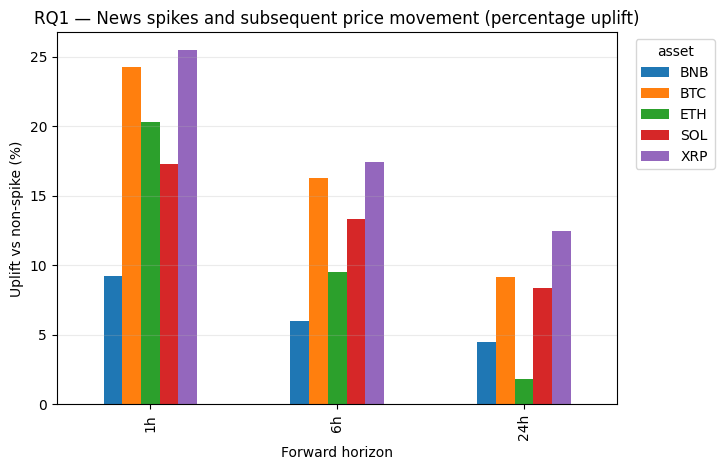

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

# Carica i risultati della query RQ1
rq1 = pd.read_csv("Out_31.csv")

# Separa spike vs non-spike e porta in forma wide per asset
spike = rq1[rq1["news_spike"] == 1].set_index("asset")
base  = rq1[rq1["news_spike"] == 0].set_index("asset")

hcols = ["avg_move_1h", "avg_move_6h", "avg_move_24h"]

# Uplift percentuale: (spike / non_spike - 1) * 100
uplift = (spike[hcols] / base[hcols] - 1) * 100
uplift.columns = ["1h", "6h", "24h"]

# Plot: barre raggruppate, x = orizzonte, y = uplift %
fig, ax = plt.subplots(figsize=(9, 4.8), facecolor="white")
ax.set_facecolor("white")

uplift.T.plot(kind="bar", ax=ax)

ax.set_xlabel("Forward horizon")
ax.set_ylabel("Uplift vs non-spike (%)")
ax.set_title("RQ1 — News spikes and subsequent price movement (percentage uplift)")
ax.grid(True, axis="y", alpha=0.25)
# Legenda fuori a destra
ax.legend(title="asset", loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.savefig("rq1_uplift_white.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


In [32]:
%%sql
--query per movimento precedente
WITH x AS (
  SELECT
    asset,
    ts_hour_utc,
    news_spike,

    -- movimento nelle ore PRECEDENTI
    ABS(ret_1h) AS move_same_hour,
    SUM(ABS(ret_1h)) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 1 PRECEDING AND 1 PRECEDING
    ) AS prev_move_1h,

    SUM(ABS(ret_1h)) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 6 PRECEDING AND 1 PRECEDING
    ) AS prev_move_6h,

    SUM(ABS(ret_1h)) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS prev_move_24h,

    -- controllo finestra completa nel passato
    COUNT(ret_1h) OVER (
      PARTITION BY asset
      ORDER BY ts_hour_utc
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS n24_prev
  FROM enriched_hourly_2y
  WHERE gdelt_missing = 0

)
SELECT
  asset,
  news_spike,
  COUNT(*) AS n_hours,
  AVG(move_same_hour) AS avg_move_same_hour,
  AVG(prev_move_1h)  AS avg_prev_move_1h,
  AVG(prev_move_6h)  AS avg_prev_move_6h,
  AVG(prev_move_24h) AS avg_prev_move_24h
FROM x
WHERE n24_prev = 24
GROUP BY asset, news_spike
ORDER BY asset, news_spike DESC;


,asset,news_spike,n_hours,avg_move_same_hour,avg_prev_move_1h,avg_prev_move_6h,avg_prev_move_24h
0,BNB,1,1343,0.004396,0.004442,0.027120,0.107217
1,BNB,0,15613,0.004070,0.004066,0.024353,0.097549
2,BTC,1,923,0.004097,0.004198,0.023658,0.091777
3,BTC,0,16033,0.003316,0.003310,0.019945,0.079937
4,ETH,1,925,0.005646,0.005381,0.029231,0.116468
5,ETH,0,16031,0.004681,0.004697,0.028353,0.113424
6,SOL,1,1115,0.007589,0.007227,0.044329,0.173899
7,SOL,0,15841,0.006317,0.006342,0.037984,0.152232
8,XRP,1,1809,0.006786,0.006831,0.041328,0.159901
9,XRP,0,15147,0.005572,0.005567,0.033357,0.134052


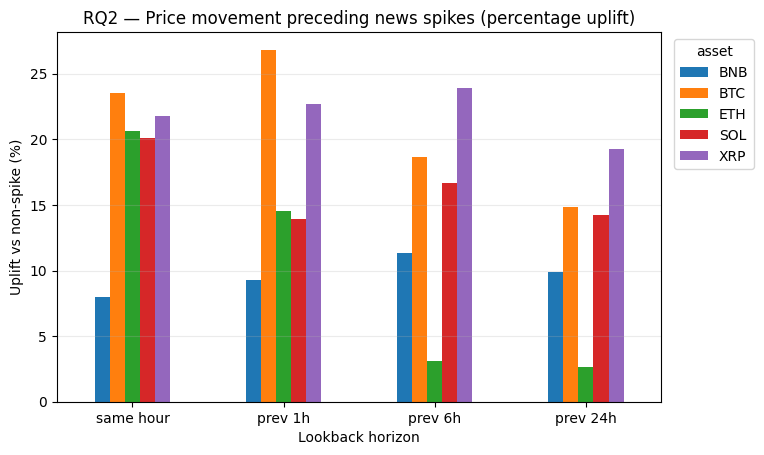

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

rq2 = pd.read_csv("Out_32.csv")

spike = rq2[rq2["news_spike"] == 1].set_index("asset")
base  = rq2[rq2["news_spike"] == 0].set_index("asset")

hcols = ["avg_move_same_hour", "avg_prev_move_1h", "avg_prev_move_6h", "avg_prev_move_24h"]

uplift = (spike[hcols] / base[hcols] - 1) * 100
uplift.columns = ["same hour", "prev 1h", "prev 6h", "prev 24h"]

fig, ax = plt.subplots(figsize=(10, 4.8))
uplift.T.plot(kind="bar", ax=ax)

ax.set_xlabel("Lookback horizon")
ax.set_ylabel("Uplift vs non-spike (%)")
ax.set_title("RQ2 — Price movement preceding news spikes (percentage uplift)")
ax.grid(True, axis="y", alpha=0.25)
ax.grid(False, axis="x")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.78, box.height])

ax.legend(
    title="asset",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),  # fuori a destra
    frameon=True
)

plt.show()


In [35]:
%%sql
--movimento trade
WITH x AS (
  SELECT
    asset,
    ts_hour_utc,
    news_spike,

    SUM(n_trades) OVER (PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 1 FOLLOWING)  AS fwd_trades_1h,

    SUM(n_trades) OVER (PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 6 FOLLOWING)  AS fwd_trades_6h,

    SUM(n_trades) OVER (PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING) AS fwd_trades_24h,

    COUNT(n_trades) OVER (PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING) AS n24
  FROM enriched_hourly_2y
  WHERE gdelt_missing = 0

)
SELECT
  asset,
  news_spike,
  COUNT(*) AS n_hours,
  AVG(fwd_trades_1h)  AS avg_fwd_trades_1h,
  AVG(fwd_trades_6h)  AS avg_fwd_trades_6h,
  AVG(fwd_trades_24h) AS avg_fwd_trades_24h
FROM x
WHERE n24 = 24
GROUP BY asset, news_spike
ORDER BY asset, news_spike DESC;



,asset,news_spike,n_hours,avg_fwd_trades_1h,avg_fwd_trades_6h,avg_fwd_trades_24h
0,BNB,1,1344,51742.994792,296744.594494,1.152511e+06
1,BNB,0,15613,38385.231986,231515.232883,9.292749e+05
2,BTC,1,924,174377.326840,961852.080087,3.585670e+06
3,BTC,0,16033,136805.296264,825762.739724,3.319955e+06
4,ETH,1,926,143136.053996,784234.258099,2.801398e+06
5,ETH,0,16031,125131.184705,755189.683052,3.042853e+06
6,SOL,1,1116,106408.190860,595732.539427,2.214070e+06
7,SOL,0,15841,77057.149486,465364.029733,1.873632e+06
8,XRP,1,1810,71165.438122,402244.435912,1.517881e+06
9,XRP,0,15147,51885.858322,314291.843863,1.268381e+06


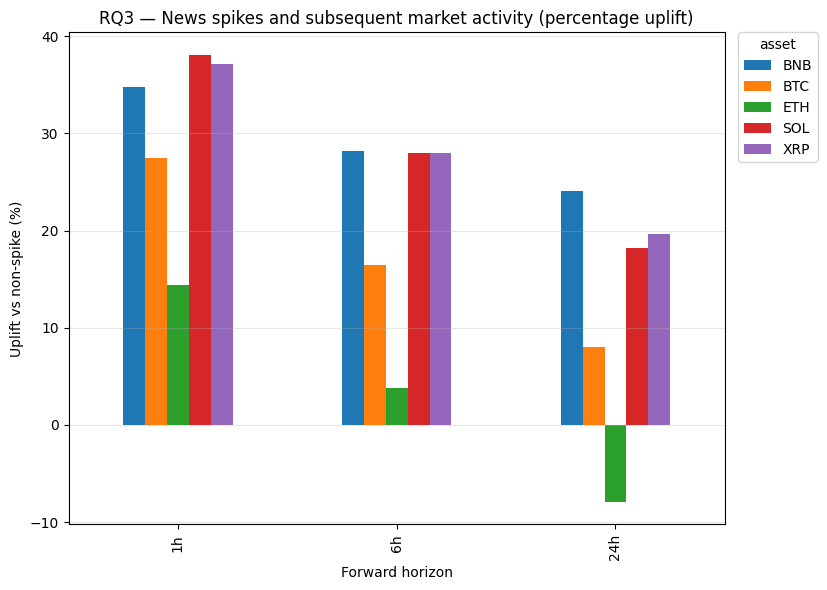

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica i risultati della query RQ3
rq3 = pd.read_csv("Out_35.csv")

# Spike vs non-spike in wide form
spike = rq3[rq3["news_spike"] == 1].set_index("asset")
base  = rq3[rq3["news_spike"] == 0].set_index("asset")

hcols = ["avg_fwd_trades_1h", "avg_fwd_trades_6h", "avg_fwd_trades_24h"]

# Uplift percentuale: (spike / non_spike - 1) * 100
uplift = (spike[hcols] / base[hcols] - 1) * 100
uplift.columns = ["1h", "6h", "24h"]

# Plot
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

uplift.T.plot(kind="bar", ax=ax)

ax.set_xlabel("Forward horizon")
ax.set_ylabel("Uplift vs non-spike (%)")
ax.set_title("RQ3 — News spikes and subsequent market activity (percentage uplift)")
ax.grid(True, axis="y", alpha=0.3)

# Legenda
ax.legend(title="asset", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.84, 1])

plt.show()


In [37]:
%%sql
-- prezzo -> spike
WITH base AS (
  SELECT
    asset,
    ts_hour_utc,
    abs_ret_1h,
    news_count_hour,
    news_spike,
    gdelt_missing
  FROM enriched_hourly_2y
  WHERE close IS NOT NULL
    AND gdelt_missing = 0
    AND abs_ret_1h IS NOT NULL
),
ranked AS (
  SELECT
    *,
    NTILE(20) OVER (PARTITION BY asset ORDER BY abs_ret_1h) AS vtile
  FROM base
),
x AS (
  SELECT
    asset,
    ts_hour_utc,
    CASE WHEN vtile = 20 THEN 1 ELSE 0 END AS price_spike,

    -- news future: considera SOLO ore osservate (gdelt_missing=0)
    SUM(CASE WHEN gdelt_missing = 0 THEN news_count_hour END) OVER (
      PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 1 FOLLOWING
    ) AS fwd_news_1h,

    SUM(CASE WHEN gdelt_missing = 0 THEN news_count_hour END) OVER (
      PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 6 FOLLOWING
    ) AS fwd_news_6h,

    SUM(CASE WHEN gdelt_missing = 0 THEN news_count_hour END) OVER (
      PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING
    ) AS fwd_news_24h,

    MAX(CASE WHEN gdelt_missing = 0 THEN news_spike END) OVER (
      PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING
    ) AS any_news_spike_24h,

    COUNT(CASE WHEN gdelt_missing = 0 THEN 1 END) OVER (
      PARTITION BY asset ORDER BY ts_hour_utc
      ROWS BETWEEN 1 FOLLOWING AND 24 FOLLOWING
    ) AS n24_obs
  FROM ranked
)
SELECT
  asset,
  price_spike,
  COUNT(*) AS n_hours,
  AVG(fwd_news_1h)  AS avg_fwd_news_1h,
  AVG(fwd_news_6h)  AS avg_fwd_news_6h,
  AVG(fwd_news_24h) AS avg_fwd_news_24h,
  AVG(any_news_spike_24h) AS p_any_news_spike_24h
FROM x
WHERE n24_obs = 24
GROUP BY asset, price_spike
ORDER BY asset, price_spike DESC;



,asset,price_spike,n_hours,avg_fwd_news_1h,avg_fwd_news_6h,avg_fwd_news_24h,p_any_news_spike_24h
0,BNB,1,849,1.327444,8.065960,31.731449,0.740872
1,BNB,0,16107,1.097163,6.573726,26.306016,0.684671
2,BTC,1,849,15.904594,93.144876,347.418139,0.517079
3,BTC,0,16107,11.905755,71.548147,287.401254,0.465139
4,ETH,1,849,8.025913,44.852768,170.857479,0.528857
5,ETH,0,16107,8.585211,51.684050,207.130875,0.506550
6,SOL,1,849,1.588928,9.903416,38.309776,0.777385
7,SOL,0,16107,1.341280,8.027566,32.171230,0.706153
8,XRP,1,849,0.771496,4.614841,16.902238,0.893993
9,XRP,0,16107,0.598684,3.592724,14.449494,0.822562


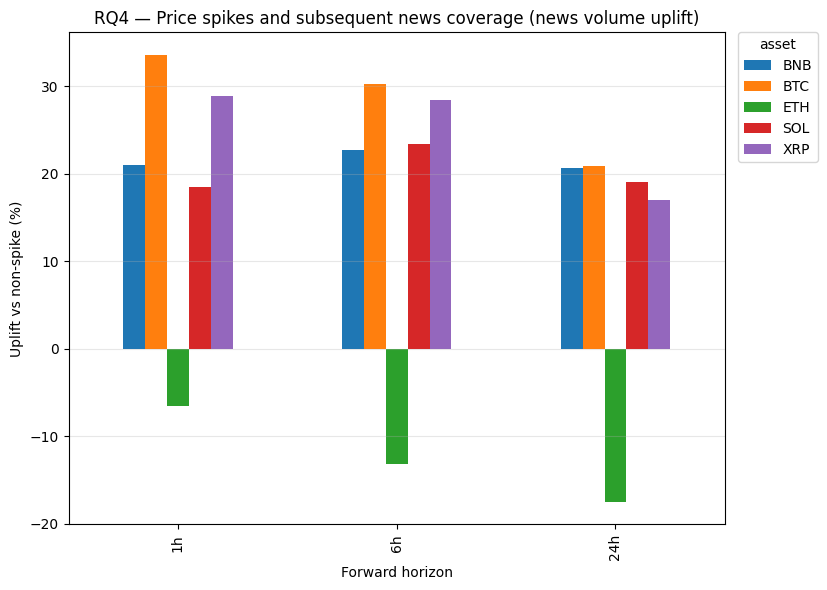

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica i risultati della query RQ4
rq4 = pd.read_csv("Out_37.csv")

# Spike vs non-spike in wide form
spike = rq4[rq4["price_spike"] == 1].set_index("asset")
base = rq4[rq4["price_spike"] == 0].set_index("asset")

# Horizon cols (news volume) + spikeprob col
hcols_news = ["avg_fwd_news_1h", "avg_fwd_news_6h", "avg_fwd_news_24h"]
pcol = ["p_any_news_spike_24h"]

# Uplift percentuale: (spike / non_spike - 1) * 100
uplift_news = (spike[hcols_news] / base[hcols_news] - 1) * 100
uplift_news.columns = ["1h", "6h", "24h"]

# plot
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

uplift_news.T.plot(kind="bar", ax=ax)

ax.set_xlabel("Forward horizon")
ax.set_ylabel("Uplift vs non-spike (%)")
ax.set_title("RQ4 — Price spikes and subsequent news coverage (news volume uplift)")
ax.grid(True, axis="y", alpha=0.3)

ax.legend(title="asset", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()



